In [1]:
# %pip install imblearn

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTENC

from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
train_data = pd.read_csv("/workspaces/Final_Project_DataScient/data/processed/train_data.csv")
test_data = pd.read_csv("/workspaces/Final_Project_DataScient/data/processed/test_data.csv")

In [4]:
train_data.columns

Index(['VETERAN3', '_AGEG5YR', '_INCOMG1', '_EDUCAG', '_CHLDCNT', 'HHADULT',
       'SEXVAR', 'MEDCOST1', '_HLTHPLN', '_AIDTST4', 'SDHEMPLY', 'SDHFOOD1',
       'SDHUTILS', 'SDHBILLS', 'SDHTRNSP', 'SLEPTIM1', 'HIVRISK5', '_TOTINDA',
       '_RFBING6', 'CVDSTRK3', 'DIABETE4', 'COVIDPOS', 'COLNCNCR', '_MICHD',
       '_ASTHMS1', '_DRDXAR2', '_PHYS14D', '_MENT14D', '_BMI5CAT', 'DECIDE',
       'DIFFALON', 'LSATISFY', 'EMTSUPRT', 'SDHISOLT', 'tobacco_use',
       'MARITAL_0.0', 'MARITAL_1.0', 'MARITAL_2.0', 'MARITAL_3.0',
       'MARITAL_4.0', 'MARITAL_5.0', 'RENTHOM1_0.0', 'RENTHOM1_1.0',
       'RENTHOM1_2.0', 'EMPLOY1_0.0', 'EMPLOY1_1.0', 'EMPLOY1_2.0',
       'EMPLOY1_3.0', 'EMPLOY1_4.0', 'EMPLOY1_5.0', 'EMPLOY1_6.0',
       'EMPLOY1_7.0', 'ADDEPEV3'],
      dtype='object')

In [5]:
X_train = train_data.drop("ADDEPEV3", axis=1)
y_train = train_data["ADDEPEV3"]

X_test = test_data.drop("ADDEPEV3", axis=1)
y_test = test_data["ADDEPEV3"]

In [11]:
y_train.value_counts()

ADDEPEV3
0.0    50991
1.0    13066
Name: count, dtype: int64

In [12]:
# 1. Obtén los índices de las columnas categóricas
all_columns = X_train.columns.tolist()
categorical_cols = [col for col in all_columns if col not in ["HHADULT", "SLEPTIM1"]]
categorical_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

# 2. Aplica SMOTENC
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_balanced, y_balanced = smote_nc.fit_resample(X_train, y_train)

In [13]:
y_balanced.value_counts()

ADDEPEV3
0.0    50991
1.0    50991
Name: count, dtype: int64

In [17]:
# Scaling
# Instantiate the scaler
scaler = MinMaxScaler().fit(X_balanced) #
# Transformation and conversion to dataframe of scaled data
X_train_scaled = pd.DataFrame(scaler.transform(X_balanced), index=X_balanced.index, columns=X_balanced.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

In [60]:
xgb = XGBClassifier(
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.2,  # ajusta según tu dataset
    eval_metric='logloss',
    random_state=42
)

In [61]:
xgb.fit(X_train_scaled, y_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
xgb_y_pred_test = xgb.predict(X_test_scaled)
xgb_y_pred_train = xgb.predict(X_train_scaled)

In [63]:
# Metrics
# Classification
accuracy_test = accuracy_score(y_test, xgb_y_pred_test)
accuracy_train = accuracy_score(y_balanced, xgb_y_pred_train)
f1_score_test = f1_score(y_test, xgb_y_pred_test)
f1_score_train = f1_score(y_balanced, xgb_y_pred_train)
precision_test = precision_score(y_test, xgb_y_pred_test)
precision_train = precision_score(y_balanced, xgb_y_pred_train)
recall_test = recall_score(y_test, xgb_y_pred_test)
recall_train = recall_score(y_balanced, xgb_y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("F1 score Test: ", f1_score_test)
print("Precision Test: ", precision_test)
print("Recall Test: ", recall_test)

print("Accuracy Train: ", accuracy_train)
print("F1 score Train: ", f1_score_train)
print("Precision Train: ", precision_train)
print("Recall Train: ", recall_train)

Accuracy Test:  0.7730252887917577
F1 score Test:  0.5459088069956277
Precision Test:  0.4695895121427036
Recall Test:  0.6518496420047732
Accuracy Train:  0.8156635484693378
F1 score Train:  0.8181123312853756
Precision Train:  0.807386754258651
Recall Train:  0.8291267086348572


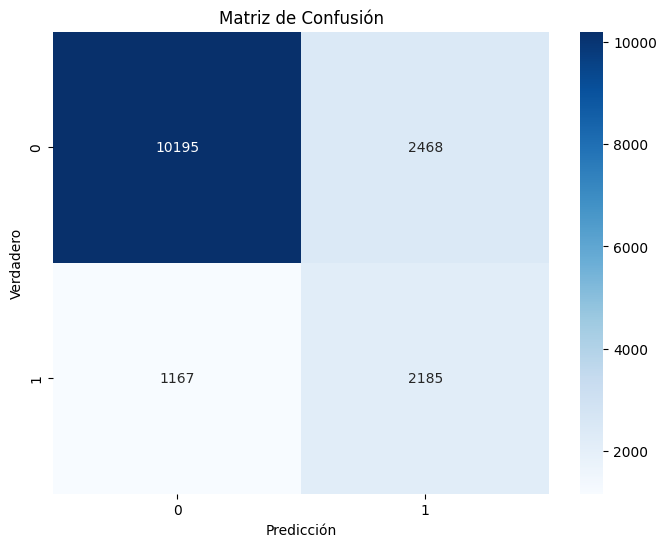

In [64]:
# Create the confusion matrix
cm = confusion_matrix(y_test, xgb_y_pred_test)

# Graph the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.show()

In [65]:
# Usa el modelo ya entrenado
y_proba = xgb.predict_proba(X_test_scaled)[:, 1]

# Prueba distintos umbrales
for t in [0.55, 0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred = (y_proba >= t).astype(int)
    print(f"Threshold: {t}")
    print("F1:", f1_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("------")

Threshold: 0.55
F1: 0.5459239130434783
Precision: 0.5012475049900199
Recall: 0.5993436754176611
------
Threshold: 0.5
F1: 0.5459088069956277
Precision: 0.4695895121427036
Recall: 0.6518496420047732
------
Threshold: 0.45
F1: 0.5444750114626318
Precision: 0.4421072226358898
Recall: 0.7085322195704057
------
Threshold: 0.4
F1: 0.5326896841221535
Precision: 0.4108790675084993
Recall: 0.7571599045346062
------
Threshold: 0.35
F1: 0.5157620746167936
Precision: 0.3809998575701467
Recall: 0.7980310262529833
------
Threshold: 0.3
F1: 0.48955957185471133
Precision: 0.34675615212527966
Recall: 0.8323389021479713
------


In [67]:
param_grid = {
    'max_depth': [3, 4, 5],                      # Profundidad de los árboles
    'learning_rate': [0.01, 0.05, 0.1],          # Menores valores mejoran generalización
    'n_estimators': [80, 100, 150],              # Más árboles si el learning_rate es bajo
    'subsample': [0.7, 0.8, 1.0],                # Fracción de muestras por árbol
    'colsample_bytree': [0.7, 0.8, 1.0],         # Fracción de columnas por árbol
    'scale_pos_weight': [1.0, 1.5, 2.0, 3.0],    # Para manejar clases desbalanceadas
    'gamma': [0, 1, 5],                          # Control de la complejidad del árbol
    'min_child_weight': [1, 3, 5]                # Regularización adicional
}

In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring={'recall': 'recall', 'precision': 'precision', 'f1': 'f1'},
    refit='recall',  # Elige el modelo con mejor recall
    cv=5,
    verbose=1,
    n_jobs=6
)

grid.fit(X_train, y_train)

# Métricas del mejor modelo:
print("Best params:", grid.best_params_)
print("Recall (test):", recall_score(y_test, grid.predict(X_test)))
print("Precision (test):", precision_score(y_test, grid.predict(X_test)))
print("F1-score (test):", f1_score(y_test, grid.predict(X_test)))